# Arithmetic MNIST — Load & Analyse


In [ ]:
import os 
import sys
sys.path.append(os.path.abspath(".."))

import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import DataLoader

# ── point this at your saved dataset folder ──────────────────────────────────
SAVE_DIR = '/Users/yassine/Desktop/CBMC/CBMC/data/generated/arithmetic_mnist/'



## 1. Load metadata & labels

In [22]:
with open(os.path.join(SAVE_DIR, 'metadata.json')) as f:
    meta = json.load(f)

print('Split      :', meta['split'])
print('Samples    :', meta['num_samples'])
print('Image size :', meta['img_size'])
print('Operators  :', meta['operators'])
print('Label cols :', meta['label_cols'])


Split      : train
Samples    : 100000
Image size : 224
Operators  : ['+', '-', 'x', '/']
Label cols : ['left_digit', 'right_digit', 'op_idx', 'result']


In [23]:
labels = torch.load(os.path.join(SAVE_DIR, 'labels.pt')).numpy()
# columns: left_digit | right_digit | op_idx | result

left   = labels[:, 0].astype(int)
right  = labels[:, 1].astype(int)
op_idx = labels[:, 2].astype(int)
result = labels[:, 3]

op_names = np.array(meta['operators'])
ops      = op_names[op_idx]        # string operator per sample

print(f'Labels shape: {labels.shape}')
print('First 5 rows (left, right, op_idx, result):')
print(labels[:5])


Labels shape: (100000, 4)
First 5 rows (left, right, op_idx, result):
[[ 4.         6.         3.         0.6666667]
 [ 9.         2.         2.        18.       ]
 [ 9.         3.         3.         3.       ]
 [ 1.         1.         1.         0.       ]
 [ 3.         1.         2.         3.       ]]


## 2. Load the Dataset class

## 3. Distribution checks

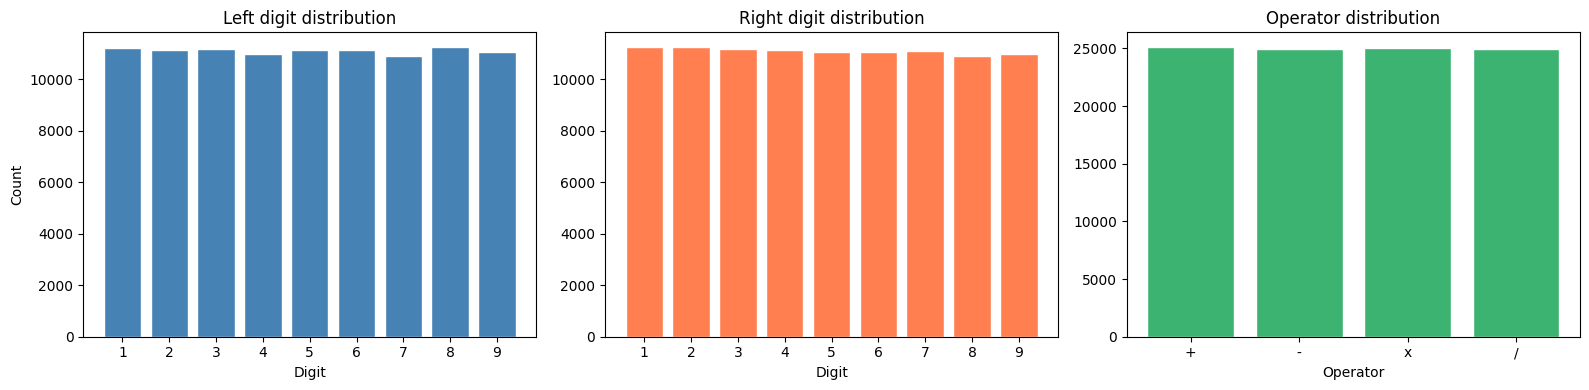

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# left digit
u, c_ = np.unique(left, return_counts=True)
axes[0].bar(u, c_, color='steelblue', edgecolor='white')
axes[0].set_title('Left digit distribution')
axes[0].set_xlabel('Digit'); axes[0].set_ylabel('Count')
axes[0].set_xticks(u)

# right digit
u, c_ = np.unique(right, return_counts=True)
axes[1].bar(u, c_, color='coral', edgecolor='white')
axes[1].set_title('Right digit distribution')
axes[1].set_xlabel('Digit')
axes[1].set_xticks(u)

# operator
u, c_ = np.unique(op_idx, return_counts=True)
axes[2].bar(op_names[u], c_, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Operator distribution')
axes[2].set_xlabel('Operator')

plt.tight_layout()
plt.show()


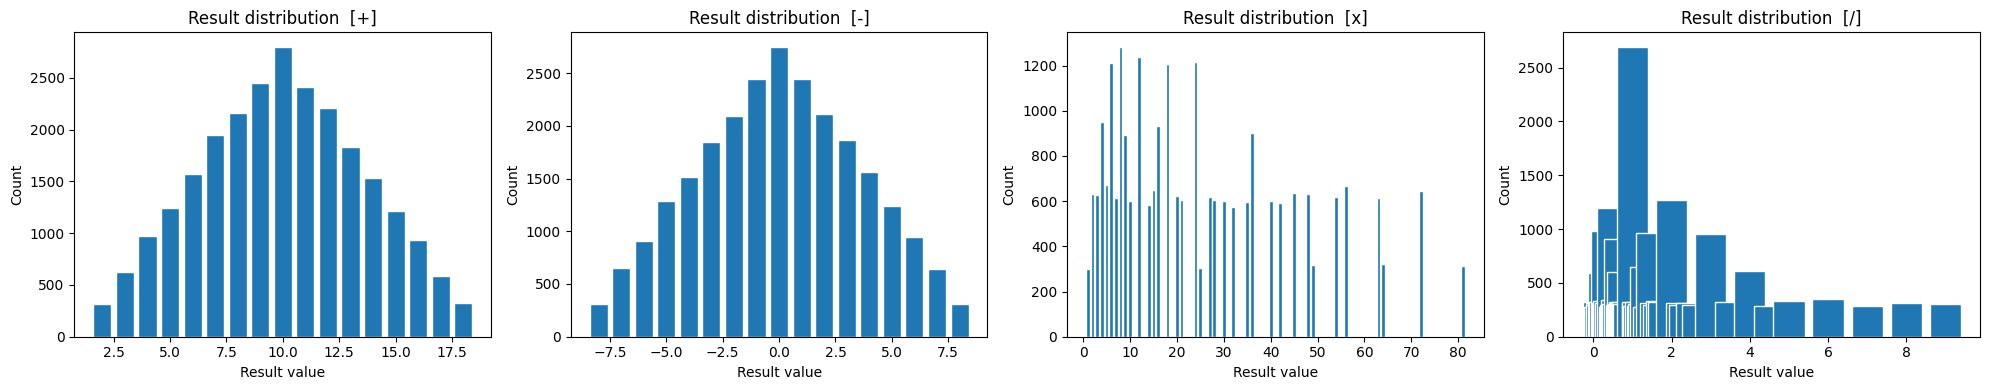

In [25]:
# Result distribution — one subplot per operator
fig, axes = plt.subplots(1, len(meta['operators']), figsize=(5*len(meta['operators']), 4))
if len(meta['operators']) == 1:
    axes = [axes]

for ax, op in zip(axes, meta['operators']):
    mask = ops == op
    res_op = result[mask]
    u, c_ = np.unique(res_op, return_counts=True)
    ax.bar(u, c_, width=0.8, edgecolor='white')
    ax.set_title(f'Result distribution  [{op}]')
    ax.set_xlabel('Result value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


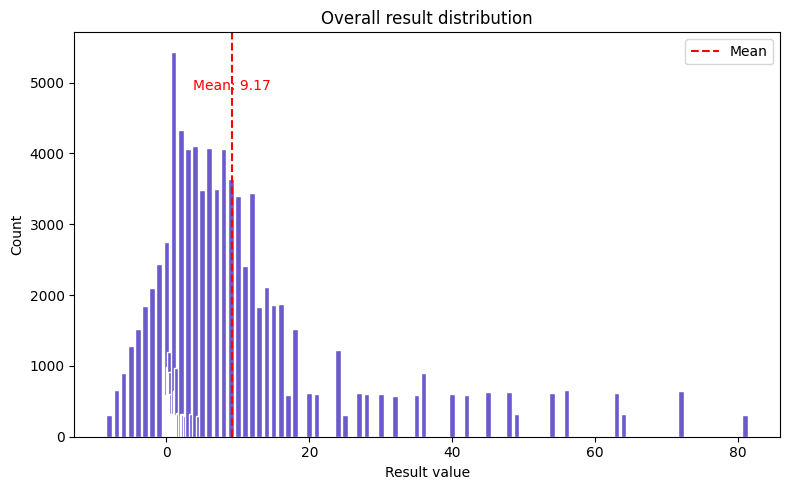

In [26]:
# a slingle plot of all the results together with a vertical line of the mean or expected value 
fig, ax = plt.subplots(figsize=(8, 5))
u, c_ = np.unique(result, return_counts=True)
ax.bar(u, c_, width=0.8, edgecolor='white', color='slateblue')
ax.set_title('Overall result distribution')
ax.set_xlabel('Result value')
ax.set_ylabel('Count')
plt.axvline(x=np.mean(result), color='red', linestyle='--', label='Mean')
# write the mean value on the plot
plt.text(np.mean(result), max(c_)*0.9, f'Mean: {np.mean(result):.2f}', color='red', ha='center')
plt.legend()
plt.tight_layout()
plt.show()


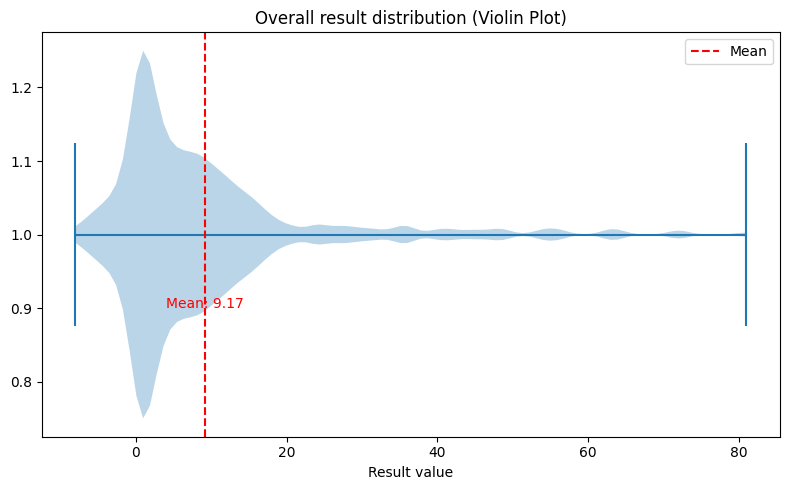

In [27]:
#same plot but voilin plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.violinplot(result, vert=False)
ax.set_title('Overall result distribution (Violin Plot)')
ax.set_xlabel('Result value')
# write the mean value on the plot
plt.axvline(x=np.mean(result), color='red', linestyle='--', label='Mean')
plt.text(np.mean(result), 0.9, f'Mean: {np.mean(result):.2f}', color='red', ha='center')
plt.legend()
plt.tight_layout()
plt.show()  


## 4. Summary statistics

In [28]:
print('='*45)
print(f'  Total samples        : {len(labels):>8}')
print(f'  Unique results       : {len(np.unique(result)):>8}')
print(f'  Result  min / max    : {result.min():>6.1f}  /  {result.max():.1f}')
print(f'  Result  mean ± std   : {result.mean():>6.2f}  ±  {result.std():.2f}')
print('='*45)

print('\nPer-operator breakdown:')
print(f'{"Op":<6} {"N":>7}  {"Result mean":>12}  {"Result std":>11}')
print('-'*40)
for op in meta['operators']:
    mask = ops == op
    r = result[mask]
    print(f'{op:<6} {mask.sum():>7}  {r.mean():>12.3f}  {r.std():>11.3f}')


  Total samples        :   100000
  Unique results       :       94
  Result  min / max    :   -8.0  /  81.0
  Result  mean ± std   :   9.17  ±  14.22

Per-operator breakdown:
Op           N   Result mean   Result std
----------------------------------------
+        25141         9.961        3.659
-        24932         0.009        3.677
x        24998        25.067       19.615
/        24929         1.583        1.721


In [29]:
# printing hte mean and stdd of + and * combined 
mask = (ops == '+') | (ops == 'x')
r = result[mask]
print(f'\nCombined [+ and x]  N={mask.sum()}  Result mean={r.mean():.3f}  Result std={r.std():.3f}')    


Combined [+ and x]  N=50139  Result mean=17.492  Result std=15.987


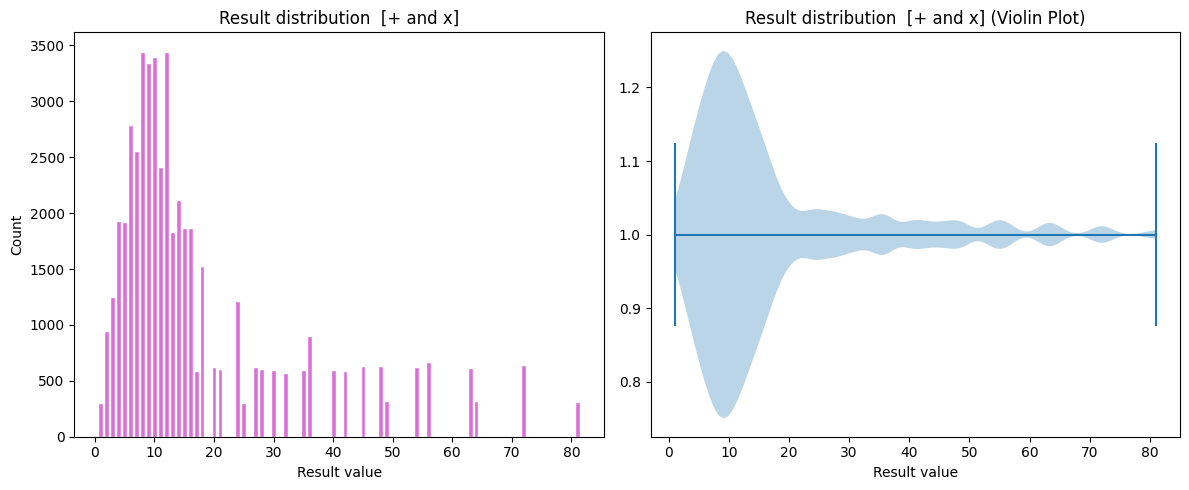

In [30]:
# plttign the result distribution of + and x combined using both a bar plot and a violin plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
# bar plot
u, c_ = np.unique(r, return_counts=True)
axes[0].bar(u, c_, color='orchid', edgecolor='white')
axes[0].set_title('Result distribution  [+ and x]')
axes[0].set_xlabel('Result value')
axes[0].set_ylabel('Count')
# violin plot
axes[1].violinplot(r, vert=False)
axes[1].set_title('Result distribution  [+ and x] (Violin Plot)')
axes[1].set_xlabel('Result value')
plt.tight_layout()
plt.show()


        